In [1]:
%cd ../..
# !pip install seaborn

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/cvfm4rehab


In [2]:
from lmms_eval.tasks.strokerehab.utils_primitives import load_strokerehab_primitives_dataset
from data.utils_strokerehab import PrimitiveLabelUtils, DataPaths
import matplotlib.pyplot as plt
import pandas as pd
import datasets

import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.4)

In [3]:
import datasets
import pandas as pd

def load_strokerehab_final():
    # Same stroke patients
    ds = load_strokerehab_primitives_dataset(patients="S00013,S00016,S00023,S00011,S00017", reps="first")
    df_stroke = ds['test'].to_pandas()

    # C00026 -> C00027. Filter out double shelf/RTT exercises for control
    ds = load_strokerehab_primitives_dataset(patients="C00022,C00023,C00024,C00028,C00029", reps="first")
    df_control = ds['test'].to_pandas()
    df_control = df_control[~df_control['activity'].isin(['shelf left side', 'RTT left side'])]

    df_combined = pd.concat([df_stroke, df_control], ignore_index=True)

    dataset = datasets.Dataset.from_pandas(df_combined)
    dataset_dict = datasets.DatasetDict({'test': dataset})
    return dataset_dict

ds = load_strokerehab_final()

In [4]:
ds = pd.DataFrame(ds['test'])

In [5]:
# import numpy as np
# import pandas as pd
# ds = load_strokerehab_primitives_dataset(filter_for_testset=True)
# ds = pd.DataFrame(ds['test'])
# dss = load_strokerehab_primitives_dataset(filter_for_subsampled_testset=True)
# dss = pd.DataFrame(dss['test'])
import numpy as np
print(np.sum(ds['duration_s']) / 60.)  # total length in minutes
# print(np.sum(dss['duration_s']) / 60.)  # total length

78.10119999999999


In [6]:
len(ds['duration_s'])

90

In [7]:
path_l = "S00047/S00047_shelf right side3_2.csv"

import os
len(PrimitiveLabelUtils.convert_labels_to_action_sequence(os.path.join(DataPaths.RAW_LABEL_DIR, path_l)))

46

In [8]:
import pandas as pd
ds['num_prims'] = ds['path_l'].apply(
    lambda p: len(PrimitiveLabelUtils.convert_labels_to_action_sequence(os.path.join(DataPaths.RAW_LABEL_DIR, p)))
)
ds.head()

,index,id,is_in_strokerehab_test_set,path_v,patient,stroke,activity,fps,height,width,duration_s,path_l,nlabels,subsampled_test_set,num_prims
0,3051,S00011_RTT right side1_1,False,S00011/S00011_RTT right side1_1.avi,S00011,True,RTT right side,60.0,704,1088,60.817,S00011/S00011_RTT right side1_1.csv,3650,False,66
1,3010,S00011_brushing1_1,False,S00011/S00011_brushing1_1.avi,S00011,True,brushing,60.0,1088,704,100.150,S00011/S00011_brushing1_1.csv,6010,False,73
2,3017,S00011_combing1_1,False,S00011/S00011_combing1_1.avi,S00011,True,combing,60.0,704,1088,12.383,S00011/S00011_combing1_1.csv,744,False,6
3,2993,S00011_deodrant1_1,False,S00011/S00011_deodrant1_1.avi,S00011,True,deodrant,60.0,704,1088,19.650,S00011/S00011_deodrant1_1.csv,1180,False,30
4,3036,S00011_drinking1_1,False,S00011/S00011_drinking1_1.avi,S00011,True,drinking,60.0,704,1088,25.350,S00011/S00011_drinking1_1.csv,1522,False,35


In [ ]:
from collections import defaultdict
import os

# Dictionary to accumulate durations for each action
action_durations = defaultdict(list)

for path_l in ds['path_l']:
    action_seq = PrimitiveLabelUtils.convert_labels_to_action_sequence(
        os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    )
    
    for item in action_seq:
        action = item['action']
        duration = item['duration']
        action_durations[action].append(duration)

# Convert defaultdict to regular dict if you want
action_durations = dict(action_durations)

# Example: print durations for 'reach'
print(action_durations.get('reach', []))

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

_DEFAULT_PALETTE = [
    (153, 153, 153),  # dull gray
    (0, 158, 115),    # stable/calm bluish green
    (230, 159, 0),    # orange
    (86, 180, 233),   # sky blue
    (204, 121, 167),  # purple
]

# Convert RGB tuples to hex
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(*rgb)

hex_palette = [rgb_to_hex(c) for c in _DEFAULT_PALETTE]

# Example mapping to actions
action_colors = {
    'idle': hex_palette[0],
    'reach': hex_palette[1],
    'transport': hex_palette[2],
    'reposition': hex_palette[3],
    'stabilize': hex_palette[4],
}

### A typical video has XXX minutes and XXX functional primitives.

In [11]:
import os
from tqdm import tqdm

# 2) walk through every entry’s label‐CSV, build a flat list of durations
paths = ds['path_l']
prim_durations = []
for csv_path in tqdm(paths):
    csv_path = os.path.join(DataPaths.RAW_LABEL_DIR, csv_path)
    hand = PrimitiveLabelUtils.get_handedness(csv_path)
    seq = PrimitiveLabelUtils.convert_labels_to_action_sequence(csv_path, hand)
    # pull out only the finite prim_durations
    prim_durations.extend(a['duration'] for a in seq if a['duration'] is not None)
    # for a in seq:
    #     if a['duration'] is None:
    #         print(f"Action {a} has no duration in path {csv_path}")
    #     elif a['duration'] > 10:
    #         print(f"Action {a} has duration {a['duration']} < 0.03 in path {csv_path}")
print(f"Percentage of durations below 0.03 seconds: {sum(d < 0.03 for d in prim_durations) / len(prim_durations) * 100:.2f}%")

100%|██████████| 90/90 [00:00<00:00, 94.08it/s] 

Percentage of durations below 0.03 seconds: 0.12%


In [12]:
import numpy as np
import pandas as pd

# 3) compute cumulative counts & percents at 0.1s bins
thresholds = np.arange(0.05, 1.1, 0.05)
thresholds = np.append(thresholds, 1. / 30)
thresholds = np.append(thresholds, 5)  # include 5 seconds as the last threshold
stats = []
for t in thresholds:
    cnt = sum(d <= t for d in prim_durations)
    pct = cnt / len(prim_durations) * 100
    stats.append({'≤ t (s)': round(t, 2), 'count': cnt, 'percent (%)': round(pct, 2)})

df_stats = pd.DataFrame(stats)

# 4) print the table
print(df_stats)

    ≤ t (s)  count  percent (%)
0      0.05     28         0.69
1      0.10    138         3.40
2      0.15    269         6.63
3      0.20    417        10.28
4      0.25    570        14.05
5      0.30    693        17.09
6      0.35    810        19.97
7      0.40    934        23.03
8      0.45   1043        25.71
9      0.50   1168        28.80
10     0.55   1271        31.34
11     0.60   1407        34.69
12     0.65   1566        38.61
13     0.70   1706        42.06
14     0.75   1910        47.09
15     0.80   2042        50.35
16     0.85   2175        53.62
17     0.90   2320        57.20
18     0.95   2476        61.05
19     1.00   2621        64.62
20     1.05   2719        67.04
21     0.03      9         0.22
22     5.00   3963        97.71


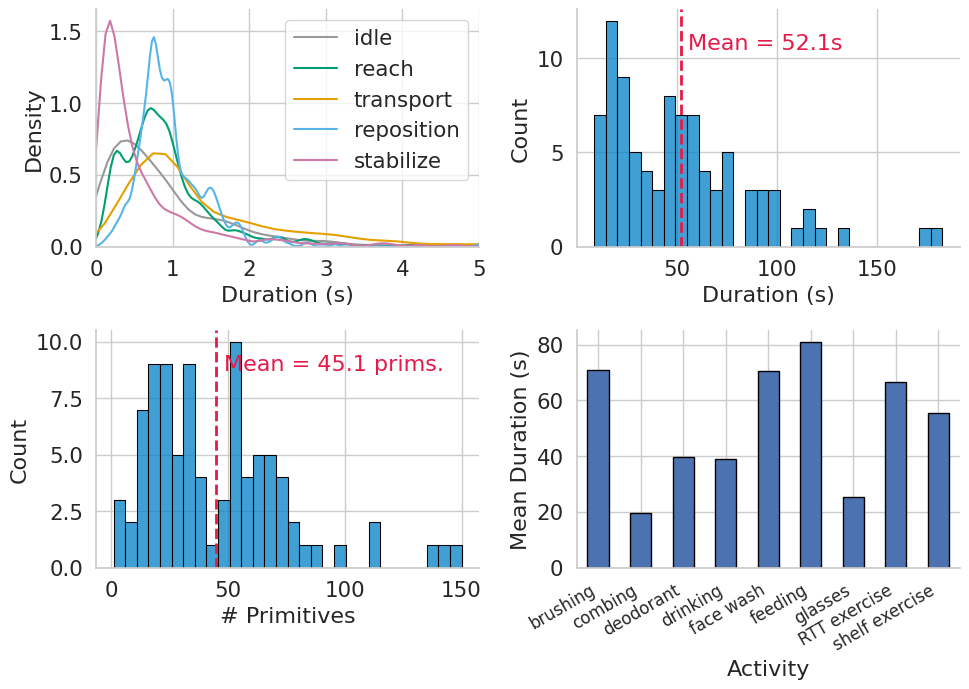

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

durations = ds['duration_s']
num_prims = ds['num_prims']
prim_durations = np.array(prim_durations)


# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(10, 7.2))
axes = axes.flatten()  # Flatten to easily index with 0..3

# 🔹 (a) KDE plot of action durations
ax = axes[0]
for action, action_duration in action_durations.items():
    sns.kdeplot(
        action_duration,
        label=action,
        color=action_colors.get(action, 'gray'),
        bw_method=0.1,
        ax=ax
    )
ax.set_xlabel("Duration (s)", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_xlim(0, 5)
# ax.set_title("(a) Action Durations KDE", loc="left", fontsize=14, fontweight="bold")
ax.legend()

# List of data, titles, and units for the remaining 3 histograms
data_list = [durations, num_prims]  # replace durations with the relevant data for each panel
titles = ["Duration (s)", "# Primitives"]
text_labels = ["s", " prims."]

for i, (ax, data, title, text_label) in enumerate(zip(axes[1:], data_list, titles, text_labels)):
    if i == 2:
        # For primitive durations, define bins only within 0–5
        bins = np.linspace(0, 5, 30)
        sns.histplot(data, bins=bins, color="#0081c7", edgecolor="black", ax=ax)
        ax.set_xlim(0, 5)
    else:
        sns.histplot(data, bins=30, color="#0081c7", edgecolor="black", ax=ax)

    mean_val = np.mean(data)
    ax.axvline(mean_val, color="#e51a49", linestyle="--", linewidth=2)
    ax.text(mean_val * 1.07, ax.get_ylim()[1]*0.9,
            f"Mean = {mean_val:.1f}{text_label}",
            color="#e51a49", ha="left", va="top", fontsize=16)

    ax.set_xlabel(title, fontsize=16)
    ax.set_ylabel("Count", fontsize=16)


# Last one
ax = axes[-1]
def get_cleaned_activity(s):
    if 'RTT' in s:
        return 'RTT exercise'
    elif 'shelf' in s:
        return 'shelf exercise'
    elif s == 'deodrant':
        return 'deodorant'
    else:
        return s

ds['cleaned_activity'] = ds['activity'].apply(get_cleaned_activity)
mean_durations = ds.groupby('cleaned_activity')['duration_s'].mean().sort_index(key=lambda x: x.str.lower())  # alphabetical sort
mean_durations.plot(kind='bar', edgecolor="black", ax=ax)
ax.set_xlabel("Activity", fontsize=16)
ax.set_ylabel("Mean Duration (s)", fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("activity_metadata_plot.pdf", bbox_inches="tight")
plt.show()
